# Buck Converter — Steady-State Analysis

Determine the duty cycle, inductor value, and output capacitor for a 12V→3.3V buck converter at 500kHz. The analytical CCM (continuous conduction mode) solution provides exact expected values. The PySpice/ngspice switching simulation solves the same circuit numerically — agreement validates the model and toolchain.

## Assumptions
- Ideal MOSFET switch (zero on-resistance, instantaneous switching)
- Ideal Schottky diode (zero forward voltage drop)
- Continuous conduction mode (CCM) — inductor current never reaches zero
- Constant input voltage (no source impedance)
- No parasitic resistance in inductor or capacitor (no ESR)
- Room temperature (no thermal derating)
- Steady-state operation (transient startup ignored)

In [1]:
# Symbolic derivation — buck converter steady-state
import sympy as sp

V_in, V_out, D, f_sw, I_load = sp.symbols("V_in V_out D f_sw I_load", positive=True)
DELTA_I, DELTA_V = sp.symbols("Delta_I Delta_V", positive=True)
L, C = sp.symbols("L C", positive=True)

# Duty cycle: D = V_out / V_in (ideal CCM, no diode drop)
D_expr = V_out / V_in
print(f"Duty cycle: D = {D_expr}")

# Inductor sizing from ripple requirement
# During ON time: V_L = V_in - V_out, dt = D/f_sw
# DELTA_I = V_L * dt / L = (V_in - V_out) * D / (f_sw * L)
# Substituting D = V_out/V_in:
# DELTA_I = V_out * (1 - D) / (f_sw * L)
L_expr = V_out * (1 - D) / (f_sw * DELTA_I)
print(f"\nInductor: L = {L_expr}")

# Output capacitor from voltage ripple requirement
# DELTA_V = DELTA_I / (8 * f_sw * C)
C_expr = DELTA_I / (8 * f_sw * DELTA_V)
print(f"\nOutput cap: C = {C_expr}")

Duty cycle: D = V_out/V_in

Inductor: L = V_out*(1 - D)/(Delta_I*f_sw)

Output cap: C = Delta_I/(8*Delta_V*f_sw)


In [2]:
# Plug in actual values with pint + uncertainties
import pint
from uncertainties import ufloat

ureg = pint.UnitRegistry()

# Input parameters
v_in = 12.0 * ureg.V
v_out = 3.3 * ureg.V
i_load = 1.0 * ureg.A
f = 500.0 * ureg.kHz
ripple_ratio = 0.30  # ΔI_L / I_load

# Derived
d = (v_out / v_in).to(ureg.dimensionless)
delta_i = ripple_ratio * i_load
delta_v = 0.01 * v_out  # 1% output voltage ripple

# Minimum inductor
l_min = (v_out * (1 - d.magnitude) / (f.to(ureg.Hz) * delta_i)).to(ureg.uH)

# Minimum output capacitor
c_min = (delta_i / (8 * f.to(ureg.Hz) * delta_v)).to(ureg.uF)

print(f"Duty cycle: D = {d:.4f}")
print(f"Inductor current ripple: ΔI_L = {delta_i:.2f}")
print(f"Min inductor: L_min = {l_min:.1f}")
print(f"Min output cap: C_min = {c_min:.1f}")

# Selected components (next standard value above minimum)
l_sel = ufloat(22.0, 2.2) * ureg.uH   # 22 uH ±10%
c_sel = ufloat(22.0, 4.4) * ureg.uF   # 22 uF ±20%
print(f"\nSelected inductor: {l_sel}")
print(f"Selected output cap: {c_sel}")

Duty cycle: D = 0.2750 dimensionless
Inductor current ripple: ΔI_L = 0.30 ampere
Min inductor: L_min = 16.0 microhenry
Min output cap: C_min = 2.3 microfarad

Selected inductor: 22.0+/-2.2 microhenry
Selected output cap: 22+/-4 microfarad


## Expected Values

| Parameter | Value | Tolerance |
|-----------|-------|-----------|
| Output voltage | 3.3 V | ±10% (open-loop, no feedback) |
| Duty cycle | 0.275 | exact (ideal) |
| Inductor current ripple | 0.30 A pk-pk | — |
| Output voltage ripple | 33 mV pk-pk | — |

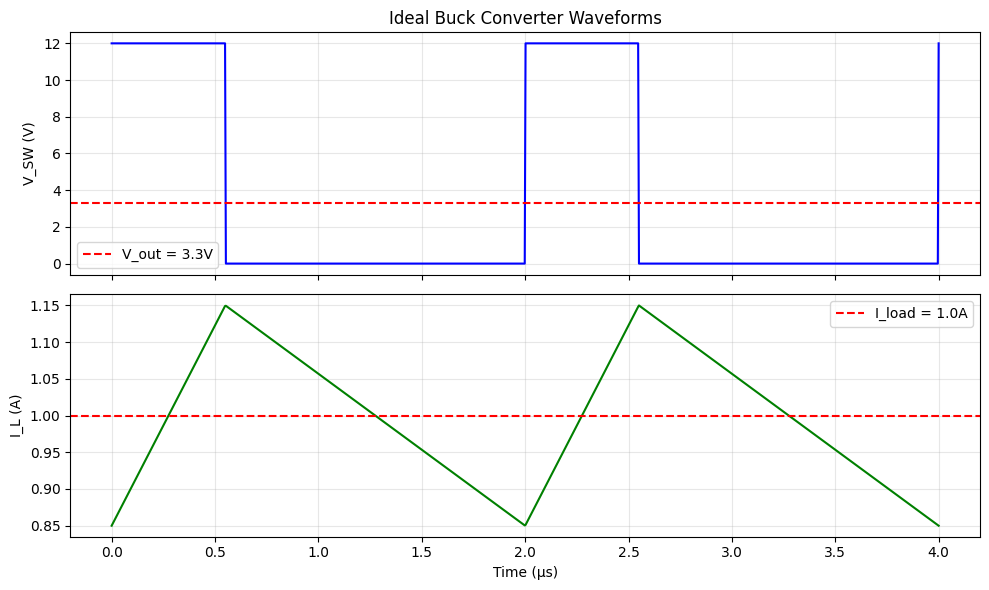

In [3]:
# Verification plot — ideal buck converter waveforms
import numpy as np
import matplotlib.pyplot as plt

d_val = 0.275
v_in_val = 12.0
v_out_val = d_val * v_in_val
f_val = 500e3
T = 1 / f_val

# Two switching cycles
t = np.linspace(0, 2 * T, 1000)
t_us = t * 1e6

# Switch node voltage (ideal)
v_sw = np.where((t % T) < d_val * T, v_in_val, 0)

# Inductor current (triangular ripple around I_load)
i_load_val = 1.0
delta_i_val = 0.30
i_l = np.zeros_like(t)
for k in range(len(t)):
    t_in_cycle = t[k] % T
    if t_in_cycle < d_val * T:
        i_l[k] = i_load_val - delta_i_val/2 + (delta_i_val / (d_val * T)) * t_in_cycle
    else:
        t_off = t_in_cycle - d_val * T
        i_l[k] = i_load_val + delta_i_val/2 - (delta_i_val / ((1-d_val) * T)) * t_off

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(t_us, v_sw, 'b-', linewidth=1.5)
ax1.set_ylabel('V_SW (V)')
ax1.set_title('Ideal Buck Converter Waveforms')
ax1.axhline(y=v_out_val, color='r', linestyle='--', label=f'V_out = {v_out_val:.1f}V')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_us, i_l, 'g-', linewidth=1.5)
ax2.set_ylabel('I_L (A)')
ax2.set_xlabel('Time (µs)')
ax2.axhline(y=i_load_val, color='r', linestyle='--', label=f'I_load = {i_load_val:.1f}A')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sim/results/ideal_waveforms.png', dpi=150)
plt.show()